# Wine Classification

The primary goal of this supervised ML classification problem is to classify wine into two categories: white and red. The model's focus is on achieving high accuracy for both categories, ensuring that both white and red wines are correctly identified as much as possible. This classification task is important because it directly impacts decision-making processes that rely on distinguishing between these two wine types.


The dataset is obtained from https://www.kaggle.com/datasets/rajyellow46/wine-quality. 

### Exploratory Data Analysis

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white



 Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'type'] 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6487 non-null   float64
 1   volatile acidity      6489 non-null   float64
 2   citric acid           6494 non-null   float64
 3   residual sugar        6495 non-null   float64
 4   chlorides             6495 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6488 non-null   float64
 9   sulphates             6493 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality             

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
17,NaN,0.660,0.48,1.2,0.029,29.0,75.0,0.98920,3.33,0.39,12.8,8,white
33,6.2,0.120,0.34,NaN,0.045,43.0,117.0,0.99390,3.42,0.51,9.0,6,white
54,6.8,0.200,0.59,0.9,0.147,38.0,132.0,0.99300,NaN,0.38,9.1,6,white
86,7.2,NaN,0.63,11.0,0.044,55.0,156.0,0.99740,3.09,0.44,8.7,6,white
98,9.8,0.360,0.46,10.5,NaN,4.0,83.0,0.99560,2.89,0.30,10.1,4,white
139,8.1,0.280,0.39,1.9,0.029,18.0,79.0,0.99230,NaN,0.52,11.8,6,white
174,NaN,0.270,0.31,17.7,0.051,33.0,173.0,0.99900,3.09,0.64,10.2,5,white
224,6.3,0.495,0.22,1.8,0.046,31.0,140.0,0.99290,3.39,NaN,10.4,6,white
249,NaN,0.410,0.14,10.4,0.037,18.0,119.0,0.99600,3.38,0.45,10.0,5,white
267,NaN,0.580,0.07,6.9,0.043,34.0,149.0,0.99440,3.34,0.57,9.7,5,white


type
white    0.753886
red      0.246114
Name: proportion, dtype: float64


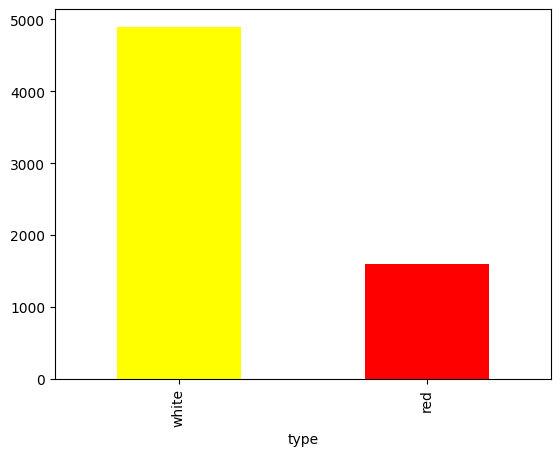

In [1]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt

# Download the dataset
path = kagglehub.dataset_download("rajyellow46/wine-quality")
file_name = "winequalityN.csv" 

df = pd.read_csv(f"{path}/{file_name}")

# Move "type" to the last column
columns = [col for col in df.columns if col != "type"] + ["type"]
df = df[columns]

display(df.head())

print(f'\n Features: {list(df.columns)} \n')

df.info()
print('\n')

# Inspect NaNs
print(df.isnull().sum().sort_values(ascending=False))
display(df[df.isnull().any(axis=1)])

print(df["type"].value_counts(normalize=True))
df["type"].value_counts().plot.bar(color=['yellow', 'red'])
plt.show()

The available features are 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'type'. In total there are 6497 samples, roughly 75% of data comes from white wine, and the remaining 25% comes from red wine, which means the dataset is slighly imbalanced. We may need to take this into account later. There are several NaNs in the dataset, which will be imputed after inspecting the distributions, and class division for 2D feature space, in a pairplot.

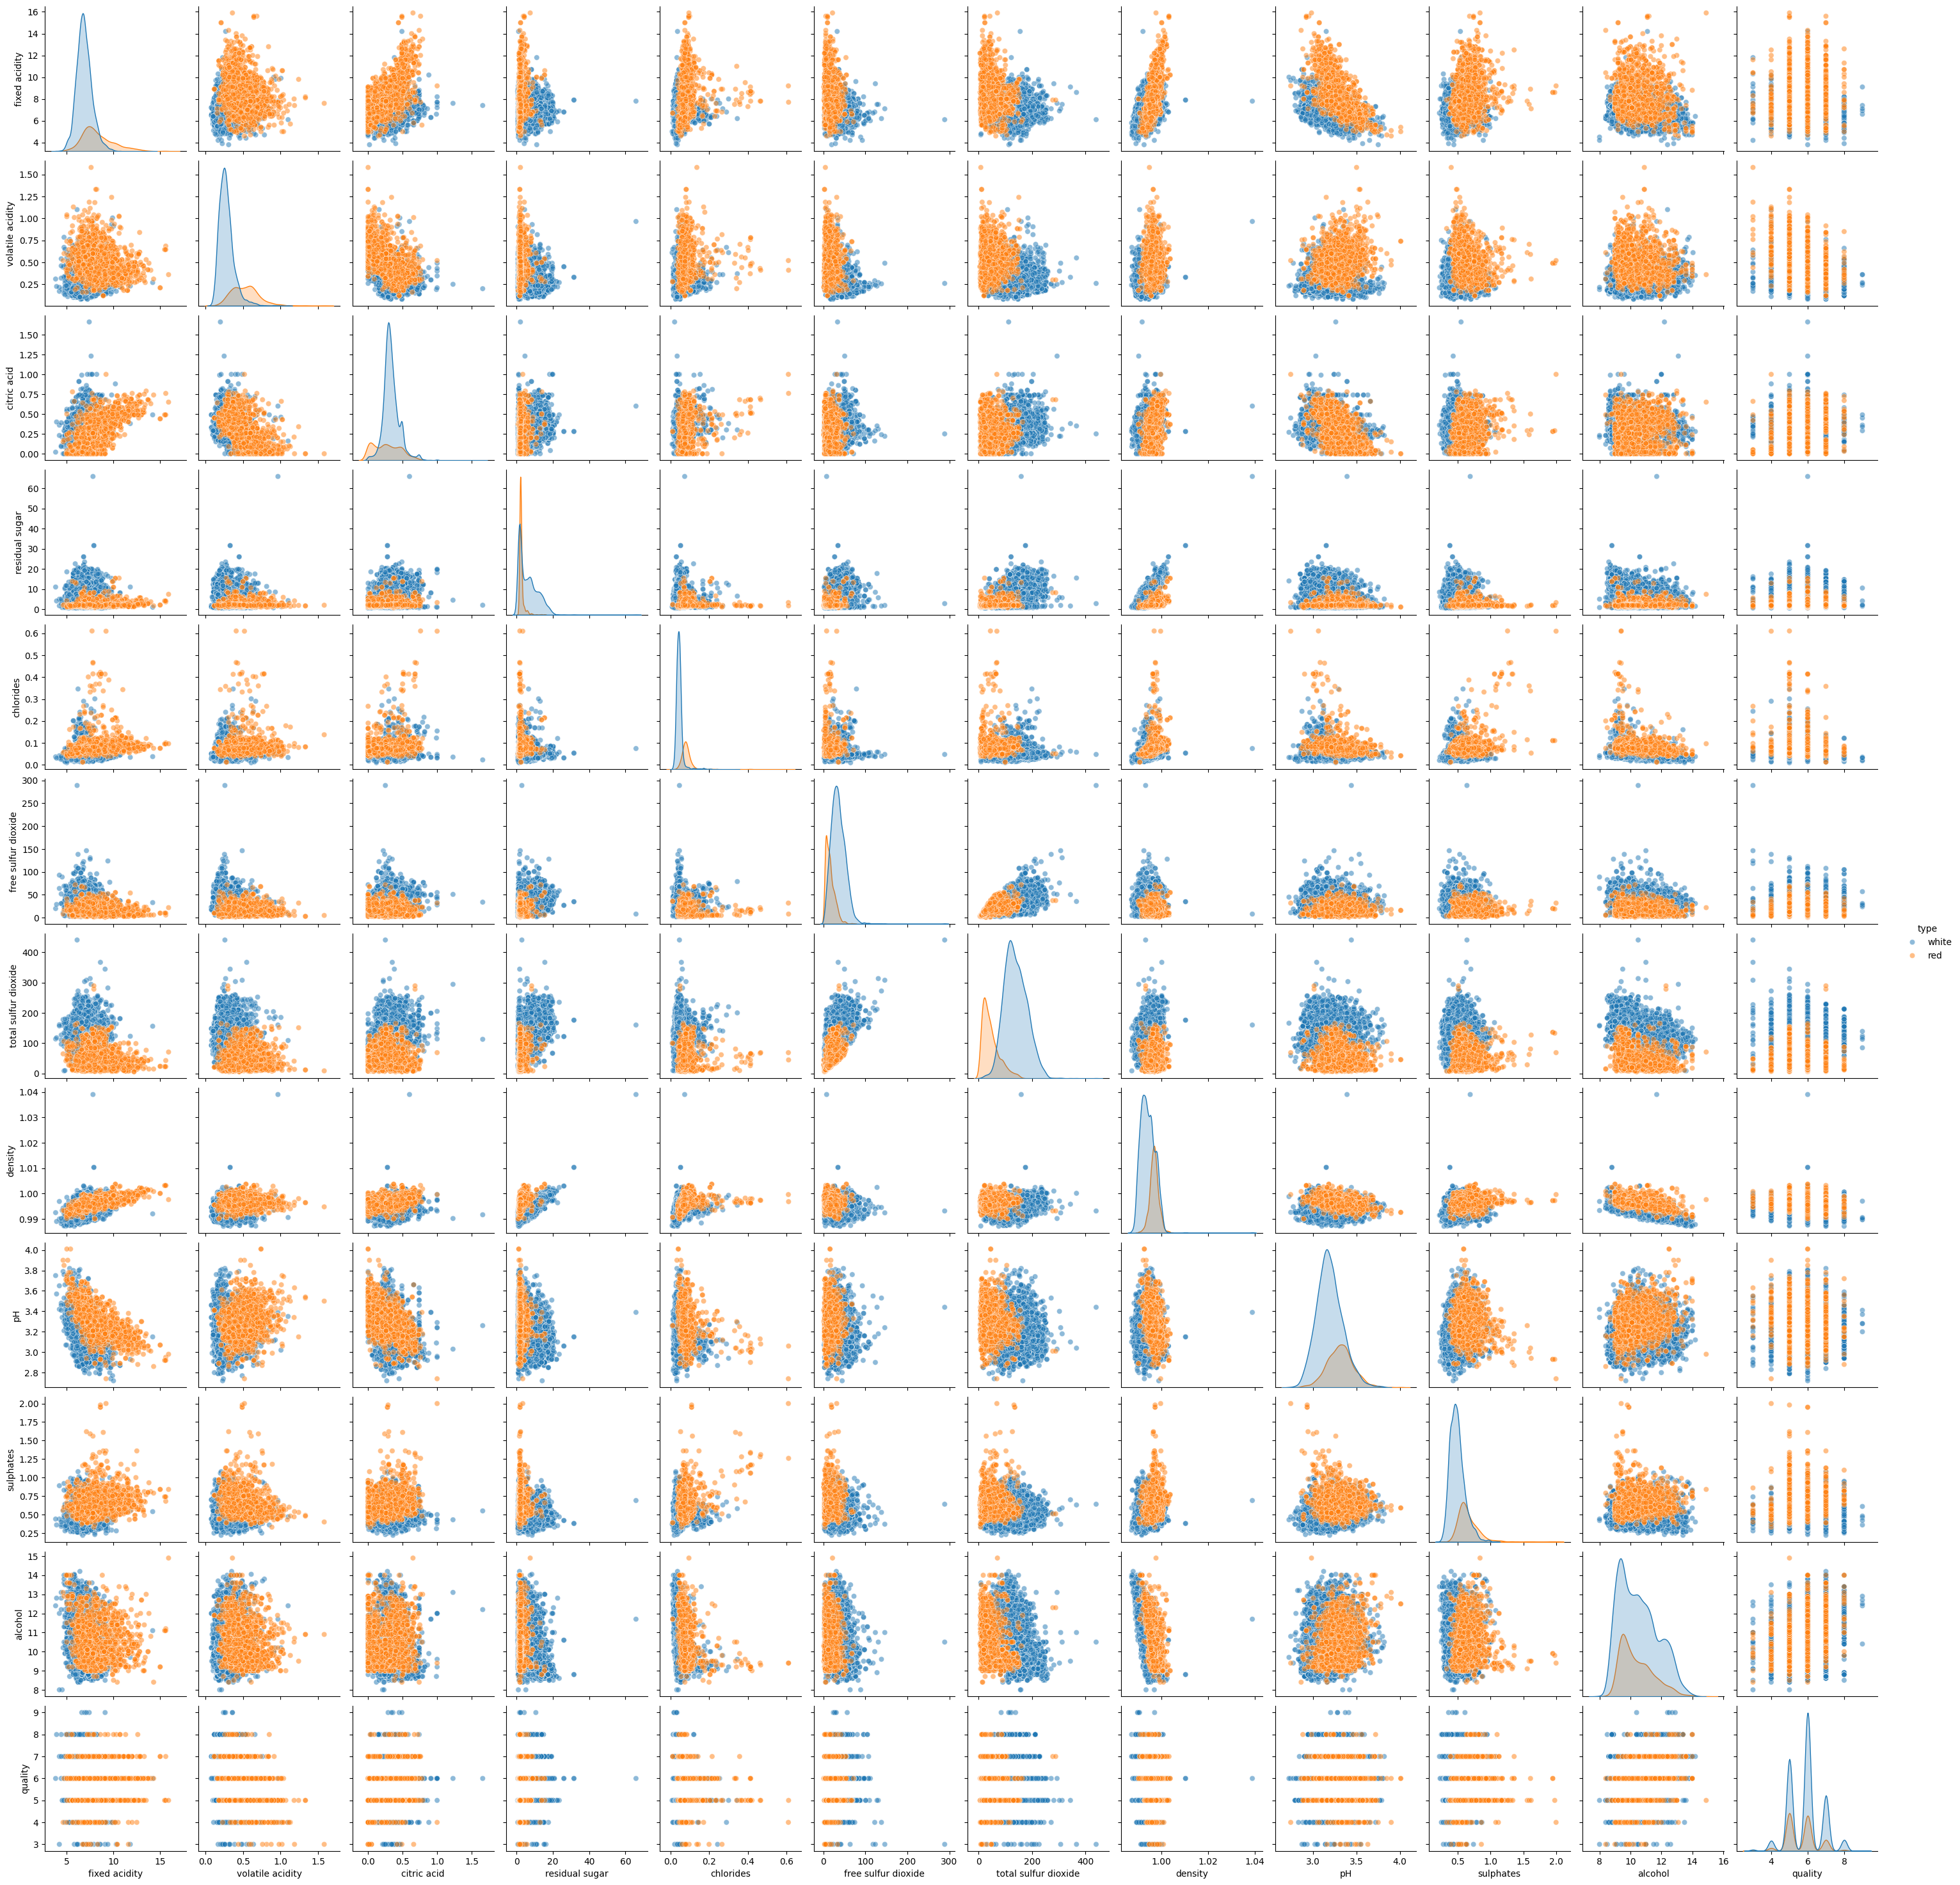

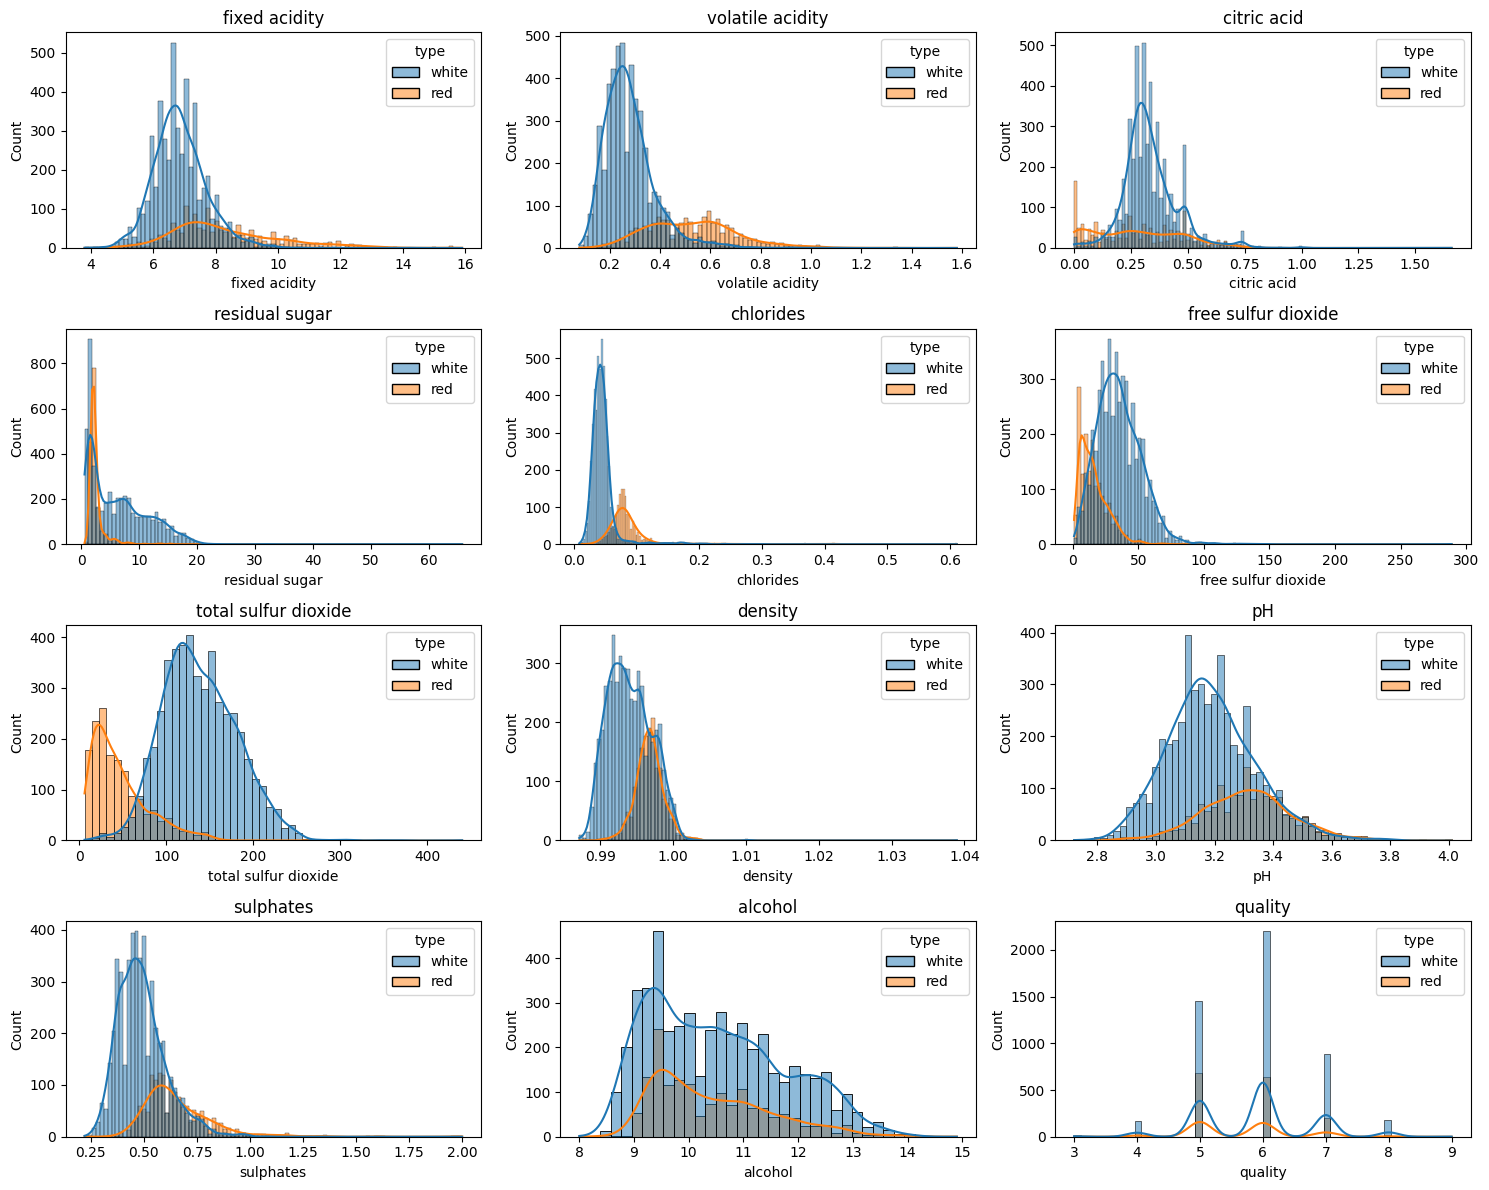

In [2]:
import seaborn as sns
import numpy as np

# Drop rows with missing values
df_clean = df.dropna()

# Create pairplot with type as hue
sns.pairplot(df_clean, hue="type", diag_kind="kde", plot_kws={'alpha': 0.5})
plt.show()

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()

# Plot distributions for each feature
for i, col in enumerate(df.select_dtypes(include=["float64", "int64"]).columns):
    sns.histplot(data=df, x=col, hue="type", kde=True, ax=axes[i], alpha=0.5)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Since most of the data follow fairly symmetric distributions without too many outliers and peaks, imputing the original dataset by the mean values is sufficient. All columns are numerical except for 'type' which is either 'white' or 'red'. Therefore, this will be binary encoded, with 0-values for white wine, and 1 for red wine.

In [3]:
# Impute missing values with the mean within each type
df_original = df.copy()
df = df.copy()
df.fillna(df.groupby("type").transform("mean"), inplace=True)
df['type_binary'] = df['type'].map({'white': 0, 'red': 1})
df = df.drop('type', axis=1)

### Feature Selection


Features and their correlation coefficient with Wine Type:
type_binary             1.000000
total sulfur dioxide    0.700357
volatile acidity        0.653029
chlorides               0.512641
fixed acidity           0.487491
sulphates               0.487110
free sulfur dioxide     0.471644
density                 0.390645
residual sugar          0.349015
pH                      0.328917
citric acid             0.187178
quality                 0.119323
alcohol                 0.032970
Name: type_binary, dtype: float64


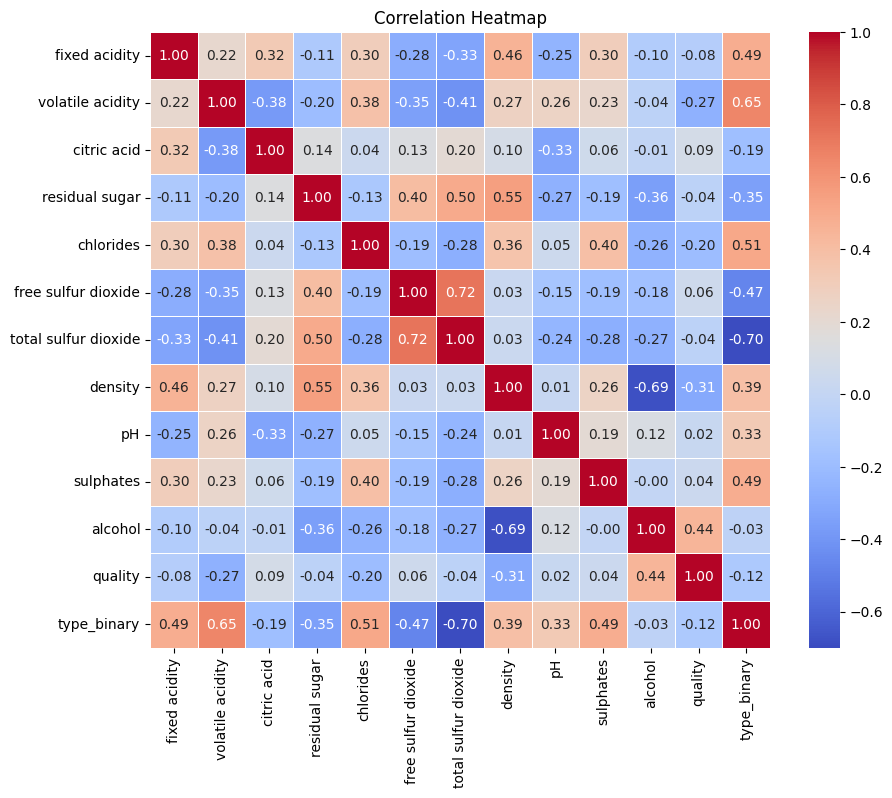

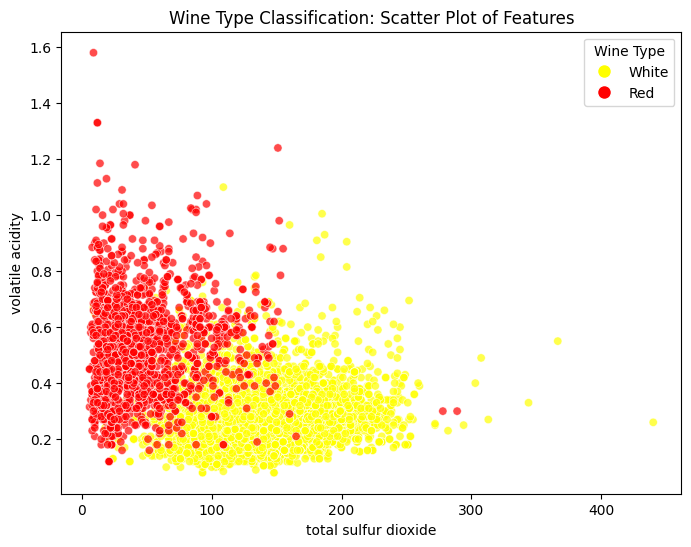

The two most correlated features are: 
['total sulfur dioxide', 'volatile acidity']


In [4]:
from matplotlib.lines import Line2D

print('Features and their correlation coefficient with Wine Type:')
print(df.corr()["type_binary"].abs().sort_values(ascending=False))
top_features = list(df.corr()["type_binary"].abs().sort_values(ascending=False).index[1:3])

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x=top_features[0], y=top_features[1], hue="type_binary", palette={0: "yellow", 1: "red"}, alpha=0.7)

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=10, label='White'),
           Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Red')]

plt.xlabel(top_features[0])
plt.ylabel(top_features[1])
plt.title("Wine Type Classification: Scatter Plot of Features")
plt.legend(title="Wine Type", handles=handles)
plt.show()

print("The two most correlated features are: ")
print(top_features)

From the correlation analysis we can find the two most correlated features with the target variable wine type and their correlation coefficient $\rho$. These are shown in the table below 

| Feature              |    $\rho$    |
|:---------------------|:-----------:|
| Total Sulfur Dioxide |  0.700357   |
| Volatile Acidity     |  0.653029   |

This is significantly higher than the 3rd most correlated factor 'chlorides' with $\rho \approx 0.51$. Therefore we go with 'total sulfur dioxide' and 'volatile acidity'. This can be justified due to their high correlation with the target, and their ability to simplify the feature space while potentially maintaining strong predictive power. 

In the feature space plot we can confirm that there may indeed be two fairly well separated distinguishable classes, which is important for predicting wine type.

### Classification
In the following section the following classification models are used based on the selected 2D feature space:

1. Logistic Regression	
2. KNearest Neighbors (KNN)
3. Decision Tree	
4. Support Vector Machines (SVM)
5. Random Forest	
6. Voting Classifier (of models 1-5)	
7. Stacking Classifier (of models 1-5) 

And resampled versions:
8. Random Forest (SMOTE)	
9. Random Forest (Random Under Sampling)	
10. Random Forest (Outliers removed)

The resampled version are done to see if Red Wine classification improves, since the imbalanced dataset may under represent wine. To minimize this potential issue models 1-7 use stratified sampling for train-test splits.

All these models are checked on their classification scores and compared, to pick the best general model, and the best model for classifiying white and red wine respectively

In [5]:
# import all necessary ML packages for classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.impute import SimpleImputer

In [6]:
X = df[top_features]
y = df["type_binary"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
def plot_confusion_matrix_roc(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """
    Function to plot confusion matrix and ROC curve for a given model.
    
    Parameters:
    - model: The trained classifier model
    - X_train, y_train: Training data and labels
    - X_test, y_test: Test data and labels
    - model_name: The name of the model for the plot title (default is "Model")
    """
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Predicted White", "Predicted Red"], 
                yticklabels=["True White", "True Red"])
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()
    
    # Get predicted probabilities for ROC curve (for the positive class)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # ROC AUC score
    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"ROC AUC for {model_name}: {roc_auc}")
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    
    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line (random classifier)
    plt.title(f"ROC Curve for {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()
    
    
# Initialize dictionary for storing white/red wine separated results
model_performance = {
    'Model': [],
    'White Wine Precision': [],
    'White Wine Recall': [],
    'White Wine F1': [],
    'Red Wine Precision': [],
    'Red Wine Recall': [],
    'Red Wine F1': []
}


# Initialize dictionary for overall performance
overall_performance = {
    'Model': [],
    'Accuracy': [],
    'Macro F1': [],
    'Weighted F1': []
}


def add_results(model_name, y_test, y_pred):
    """
    A function which adds the classification report scores to the above dictionary (model_performance)
    Parameters:
    - model_name: Name of the model
    - y_test: Test set for wine type
    - y_pred: Predicted wine type
    """
    report = classification_report(y_test, y_pred, output_dict=True)
    white_wine_precision = report['0']['precision']
    white_wine_recall = report['0']['recall']
    white_wine_f1 = report['0']['f1-score']

    red_wine_precision = report['1']['precision']
    red_wine_recall = report['1']['recall']
    red_wine_f1 = report['1']['f1-score']

    model_performance['Model'].append(model_name)
    model_performance['White Wine Precision'].append(white_wine_precision)
    model_performance['White Wine Recall'].append(white_wine_recall)
    model_performance['White Wine F1'].append(white_wine_f1)
    model_performance['Red Wine Precision'].append(red_wine_precision)
    model_performance['Red Wine Recall'].append(red_wine_recall)
    model_performance['Red Wine F1'].append(red_wine_f1)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = report['macro avg']['f1-score']
    weighted_f1 = report['weighted avg']['f1-score']

    overall_performance['Model'].append(model_name)
    overall_performance['Accuracy'].append(accuracy)
    overall_performance['Macro F1'].append(macro_f1)
    overall_performance['Weighted F1'].append(weighted_f1)

### 1. Logistic Regression

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters found by GridSearchCV for Logistic Regression:
{'classifier__C': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Logistic Regression Model Performance:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       980
           1       0.91      0.90      0.91       320

    accuracy                           0.96      1300
   macro avg       0.94      0.94      0.94      1300
weighted avg       0.96      0.96      0.96      1300

Accuracy score: 0.9553846153846154


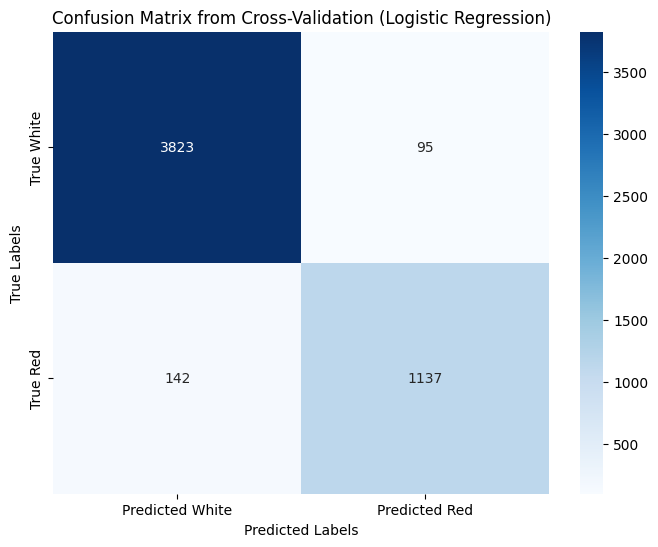

ROC AUC for Logistic Regression: 0.9856983418367347


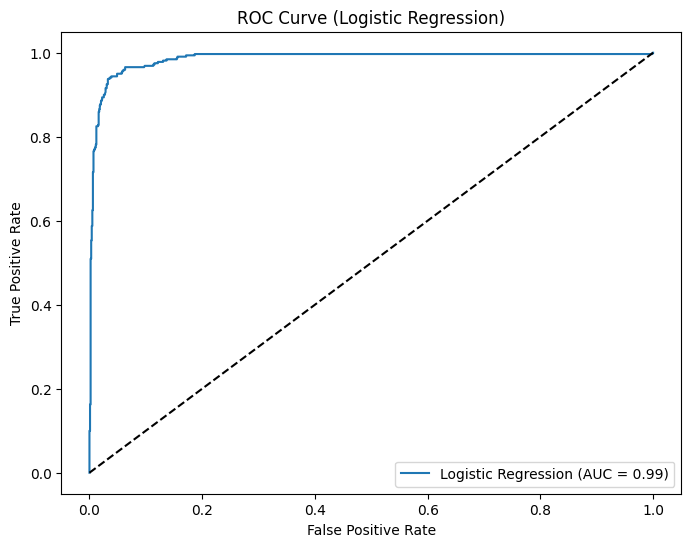

In [8]:
# Define parameter grid for Logistic Regression
param_grid_lr = {
    'classifier__C': [0.1, 1, 10, 100],  # Regularization strength
    'classifier__penalty': ['l2'],  # L2 regularization
    'classifier__solver': ['lbfgs', 'liblinear']  # Solvers for optimization
}

# Create pipeline for Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),  # Scaling for consistency
    ('classifier', LogisticRegression(random_state=42))
])

# Perform GridSearchCV for Logistic Regression
grid_search_lr = GridSearchCV(lr_pipeline, param_grid_lr, cv=5, scoring='accuracy', verbose=1)
grid_search_lr.fit(X_train, y_train)

# Best parameters for Logistic Regression
print("Best Parameters found by GridSearchCV for Logistic Regression:")
print(grid_search_lr.best_params_)

# Get the best model from GridSearchCV
best_lr_model = grid_search_lr.best_estimator_

# Predictions with the best Logistic Regression model
y_pred_lr = best_lr_model.predict(X_test)

# Print classification report
print("\nLogistic Regression Model Performance:")
print(classification_report(y_test, y_pred_lr))
print(f"Accuracy score: {accuracy_score(y_test, y_pred_lr)}")

# Perform cross-validation and get predictions
y_pred_cv_lr = cross_val_predict(best_lr_model, X_train, y_train, cv=5)

# Compute confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_train, y_pred_cv_lr)

# Plot confusion matrix for Logistic Regression
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=["Predicted White", "Predicted Red"], yticklabels=["True White", "True Red"])
plt.title("Confusion Matrix from Cross-Validation (Logistic Regression)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


# Get the predicted probabilities for the Logistic Regression model
y_prob_lr = best_lr_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class (red wine)

# Calculate the ROC AUC score
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"ROC AUC for Logistic Regression: {roc_auc_lr}")

# Plot ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line (random classifier)
plt.title("ROC Curve (Logistic Regression)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


# Add results to dictionary
add_results('Logistic Regression', y_test, y_pred_lr)

### 2. KNearest Neighbors (KNN)

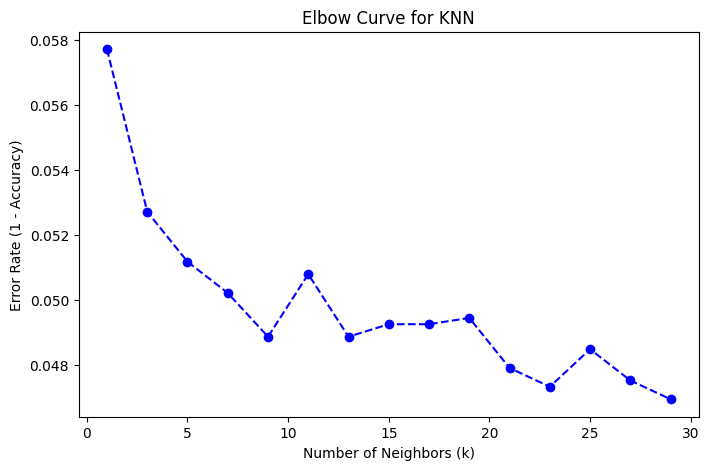

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters found by GridSearchCV for KNN:
{'classifier__n_neighbors': 29, 'classifier__p': 1, 'classifier__weights': 'distance'}

KNN Model Performance:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.93      0.93      0.93       320

    accuracy                           0.97      1300
   macro avg       0.95      0.95      0.95      1300
weighted avg       0.97      0.97      0.97      1300

Accuracy score: 0.9653846153846154


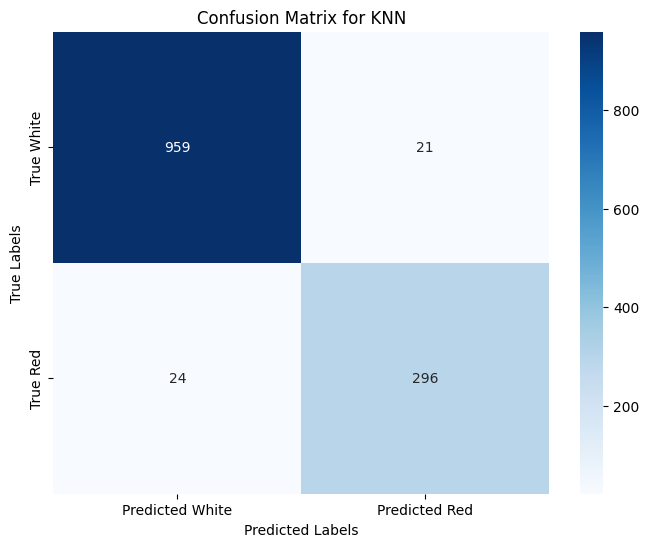

ROC AUC for KNN: 0.9860427295918366


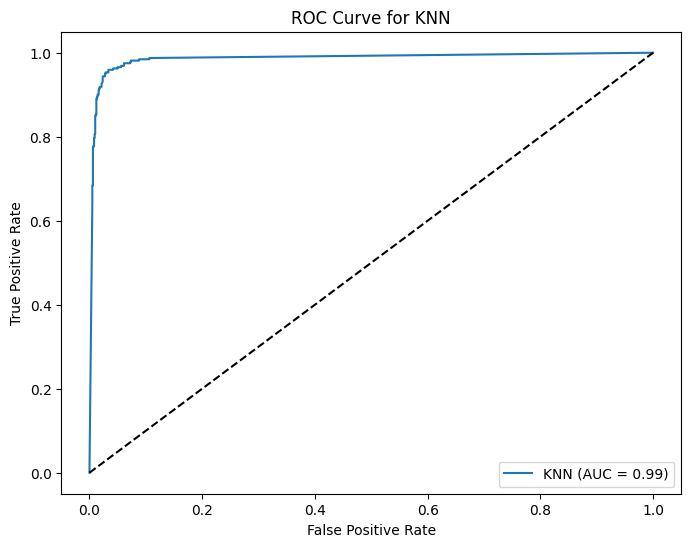

In [9]:
errors = []
k_values = list(range(1, 30, 2))  # Test odd values of k from 1 to 29

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn_pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('classifier', knn)
    ])
    
    scores = cross_val_score(knn_pipeline, X_train, y_train, cv=5, scoring='accuracy')
    errors.append(1 - scores.mean())  # Error = 1 - Accuracy

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, errors, marker='o', linestyle='dashed', color='b')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Error Rate (1 - Accuracy)')
plt.title('Elbow Curve for KNN')
plt.show()


best_k = k_values[np.argmin(errors)]  # Find k with lowest error

param_grid_knn = {
    'classifier__n_neighbors': [best_k],  # Use best k from elbow curve
    'classifier__weights': ['uniform', 'distance'],
    'classifier__p': [1, 2]
}
# Create KNN pipeline
knn_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),  # Scaling features
    ('classifier', KNeighborsClassifier())  # KNN classifier
])

# Perform Grid Search with cross-validation
grid_search_knn = GridSearchCV(knn_pipeline, param_grid_knn, cv=5, scoring='accuracy', verbose=1)

# Fit the grid search
grid_search_knn.fit(X_train, y_train)

# Best parameters from GridSearchCV
print("Best Parameters found by GridSearchCV for KNN:")
print(grid_search_knn.best_params_)

# Get the best model from the grid search
best_knn_model = grid_search_knn.best_estimator_

# Make predictions with the best model
y_pred_knn = best_knn_model.predict(X_test)

# Print classification report for KNN model
print("\nKNN Model Performance:")
print(classification_report(y_test, y_pred_knn))
print(f"Accuracy score: {accuracy_score(y_test, y_pred_knn)}")

# Perform cross-validation and get predictions
y_pred_cv_knn = cross_val_predict(best_knn_model, X_train, y_train, cv=5)

plot_confusion_matrix_roc(best_knn_model, X_train, y_train, X_test, y_test, model_name="KNN")


# Add results to dictionary
add_results('KNN', y_test, y_pred_knn)

### 3. Decision Tree

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters found by GridSearchCV for Decision Tree:
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2}

Decision Tree Model Performance:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       980
           1       0.91      0.92      0.91       320

    accuracy                           0.96      1300
   macro avg       0.94      0.94      0.94      1300
weighted avg       0.96      0.96      0.96      1300

Accuracy score: 0.9576923076923077


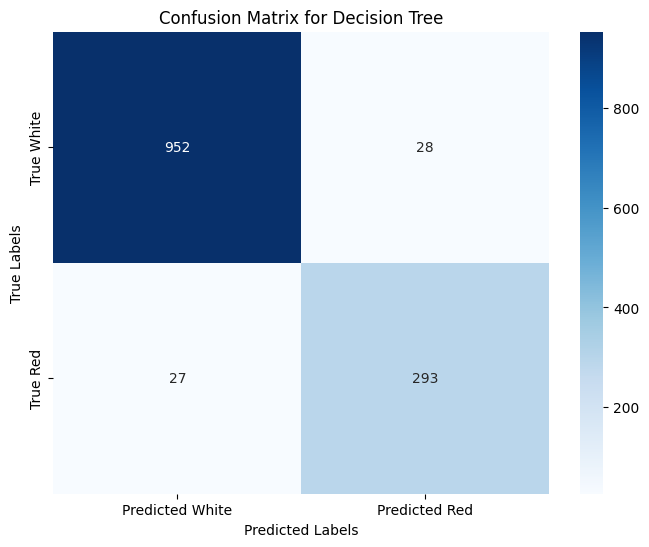

ROC AUC for Decision Tree: 0.9840880102040817


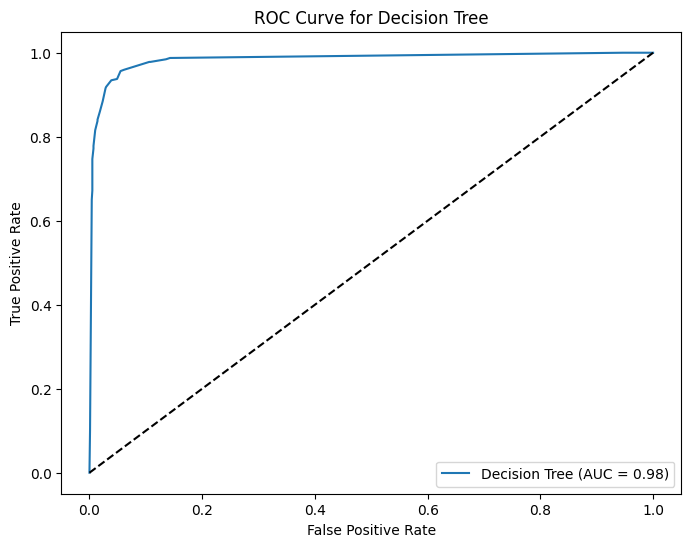

In [10]:
# Define parameter grid for Decision Tree
param_grid_dt = {
    'classifier__max_depth': [3, 5, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 5]
}

# Create pipeline for Decision Tree
dt_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),  # Scaling for consistency
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Perform GridSearchCV for Decision Tree
grid_search_dt = GridSearchCV(dt_pipeline, param_grid_dt, cv=5, scoring='accuracy', verbose=1)
grid_search_dt.fit(X_train, y_train)

# Best parameters for Decision Tree
print("Best Parameters found by GridSearchCV for Decision Tree:")
print(grid_search_dt.best_params_)

# Get the best model from GridSearchCV
best_dt_model = grid_search_dt.best_estimator_

# Predictions with the best Decision Tree model
y_pred_dt = best_dt_model.predict(X_test)

# Print classification report
print("\nDecision Tree Model Performance:")
print(classification_report(y_test, y_pred_dt))
print(f"Accuracy score: {accuracy_score(y_test, y_pred_dt)}")

# Perform cross-validation and get predictions
y_pred_cv_dt = cross_val_predict(best_dt_model, X_train, y_train, cv=5)

plot_confusion_matrix_roc(best_dt_model, X_train, y_train, X_test, y_test, model_name="Decision Tree")


# Add results to dictionary
add_results('Decision Tree', y_test, y_pred_dt)

### 4. Support Vector Machines (SVM)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters found by GridSearchCV:
{'classifier__C': 1, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}

SVM Model Performance:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       980
           1       0.91      0.91      0.91       320

    accuracy                           0.96      1300
   macro avg       0.94      0.94      0.94      1300
weighted avg       0.96      0.96      0.96      1300

Accuracy score: 0.9553846153846154


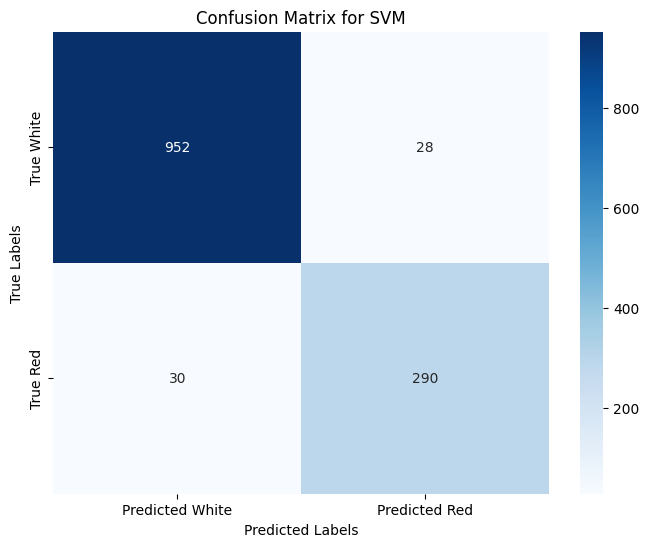

ROC AUC for SVM: 0.9856664540816326


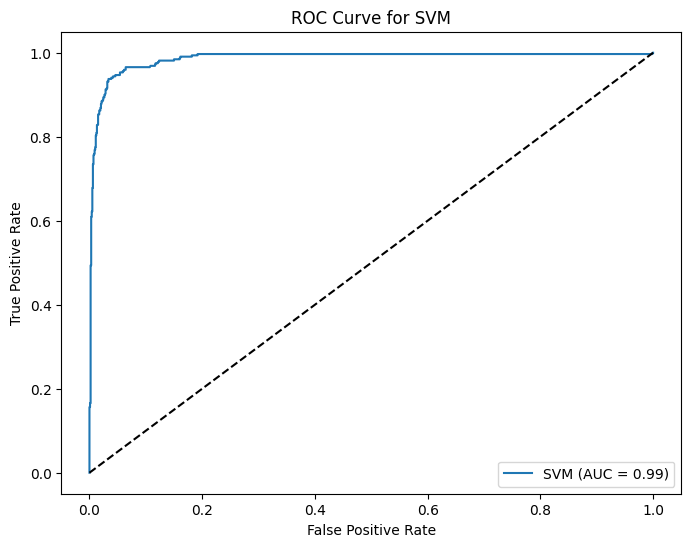

In [11]:
param_grid_svm = {
    'classifier__C': [0.1, 1, 10, 100],      
    'classifier__kernel': ['linear', 'rbf'],  
    'classifier__gamma': ['scale', 'auto'], 
}


svm_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', SVC(probability=True, random_state=42))  # Enable probability estimates
])

grid_search_svm = GridSearchCV(svm_pipeline, param_grid_svm, cv=5, scoring='accuracy', verbose=1)

grid_search_svm.fit(X_train, y_train)

# Best parameters from GridSearchCV
print("Best Parameters found by GridSearchCV:")
print(grid_search_svm.best_params_)

# Get the best model from the grid search
best_svm_model = grid_search_svm.best_estimator_

# Make predictions with the best model
y_pred_svm = best_svm_model.predict(X_test)

# Print classification report for the best model
print("\nSVM Model Performance:")
print(classification_report(y_test, y_pred_svm))
print(f"Accuracy score: {accuracy_score(y_test, y_pred_svm)}")


# Perform cross-validation and get predictions
y_pred_cv = cross_val_predict(best_svm_model, X_train, y_train, cv=5)

plot_confusion_matrix_roc(best_svm_model, X_train, y_train, X_test, y_test, model_name="SVM")


# Add results to dictionary
add_results('SVM', y_test, y_pred_svm)

### 5. Random Forest

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters found by GridSearchCV for Random Forest:
{'classifier__bootstrap': False, 'classifier__max_depth': None, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 50}

Random Forest Model Performance:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       980
           1       0.93      0.92      0.93       320

    accuracy                           0.96      1300
   macro avg       0.95      0.95      0.95      1300
weighted avg       0.96      0.96      0.96      1300

Training Accuracy (Random Forest): 0.9730613815662883
Test Accuracy (Random Forest): 0.9638461538461538


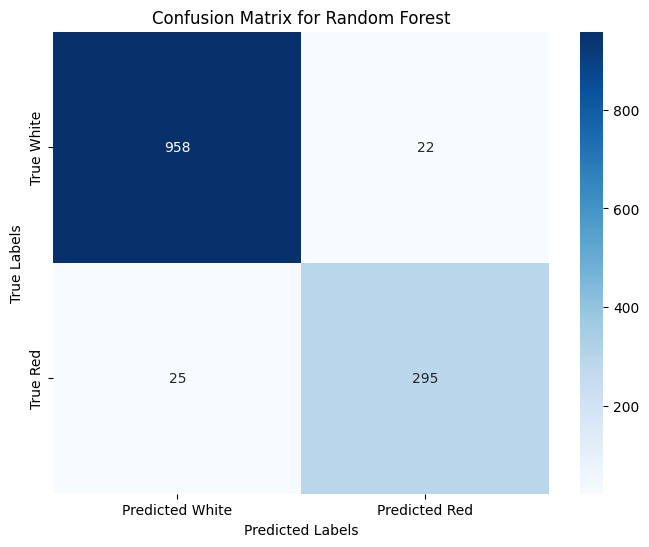

ROC AUC for Random Forest: 0.9915274234693878


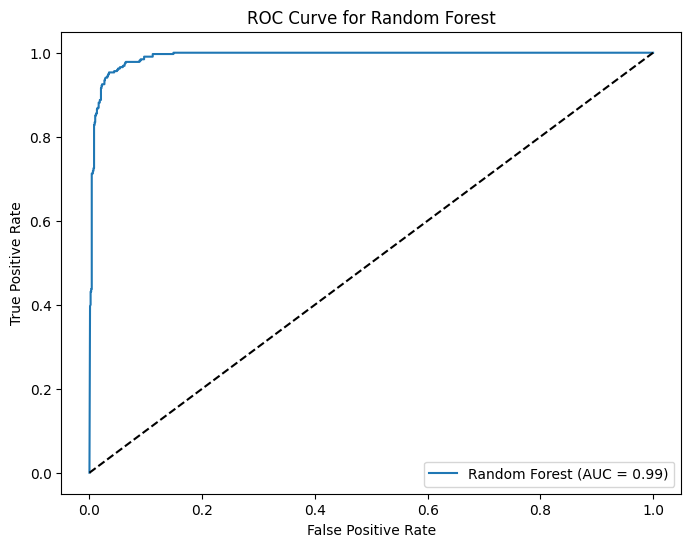

In [12]:
# Define parameter grid for Random Forest
param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False]
}

# Create pipeline for Random Forest
rf_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),  # Scaling for consistency
    ('classifier', RandomForestClassifier(random_state=42))
])

# Perform GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=5, scoring='accuracy', verbose=1)
grid_search_rf.fit(X_train, y_train)

# Best parameters for Random Forest
print("Best Parameters found by GridSearchCV for Random Forest:")
print(grid_search_rf.best_params_)

# Get the best model from GridSearchCV
best_rf_model = grid_search_rf.best_estimator_

# Predictions with the best Random Forest model
y_pred_rf = best_rf_model.predict(X_test)

# Print classification report for Random Forest
print("\nRandom Forest Model Performance:")
print(classification_report(y_test, y_pred_rf))

# Training accuracy
train_accuracy_rf = best_rf_model.score(X_train, y_train)
print(f"Training Accuracy (Random Forest): {train_accuracy_rf}")
print(f"Test Accuracy (Random Forest): {accuracy_score(y_test, y_pred_rf)}")


# Perform cross-validation and get predictions
y_pred_cv_rf = cross_val_predict(best_rf_model, X_train, y_train, cv=5)

plot_confusion_matrix_roc(best_rf_model, X_train, y_train, X_test, y_test, model_name="Random Forest")


# Add results to dictionary
add_results('Random Forest', y_test, y_pred_rf)

### 6. & 7. Voting & Stacking classification of previously used models


 Voting Classifier Model Performance:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       980
           1       0.93      0.92      0.92       320

    accuracy                           0.96      1300
   macro avg       0.95      0.95      0.95      1300
weighted avg       0.96      0.96      0.96      1300

Accuracy Score: 0.963076923076923

 Stacking Classifier Model Performance:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       980
           1       0.94      0.91      0.92       320

    accuracy                           0.96      1300
   macro avg       0.95      0.95      0.95      1300
weighted avg       0.96      0.96      0.96      1300

Accuracy Score: 0.963076923076923


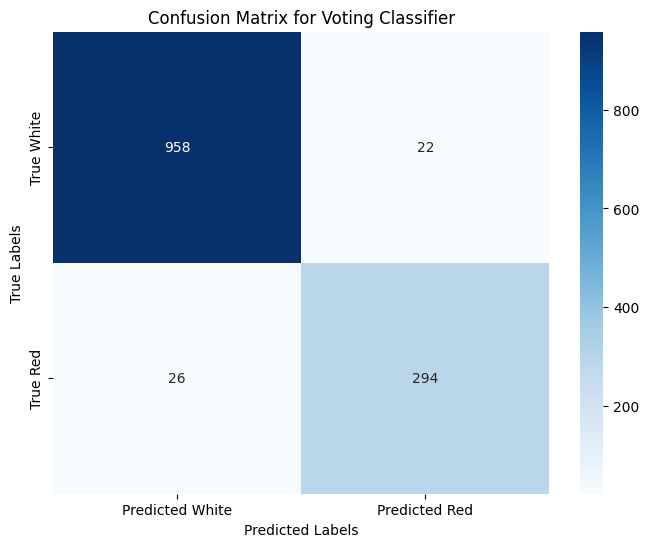

ROC AUC for Voting Classifier: 0.9920025510204082


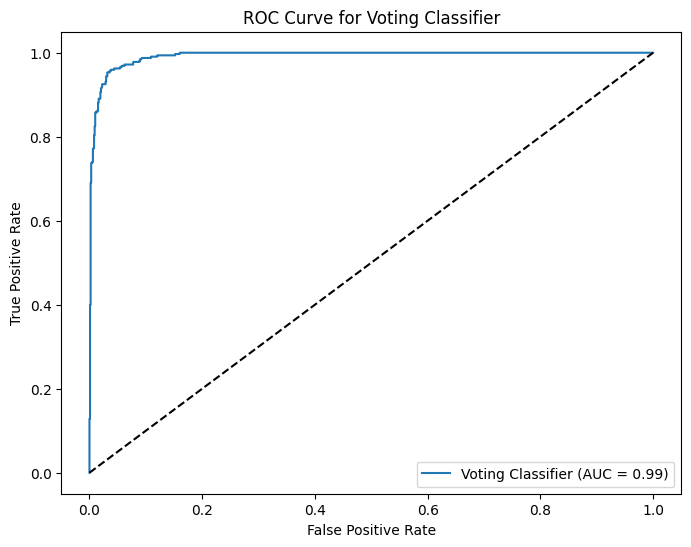

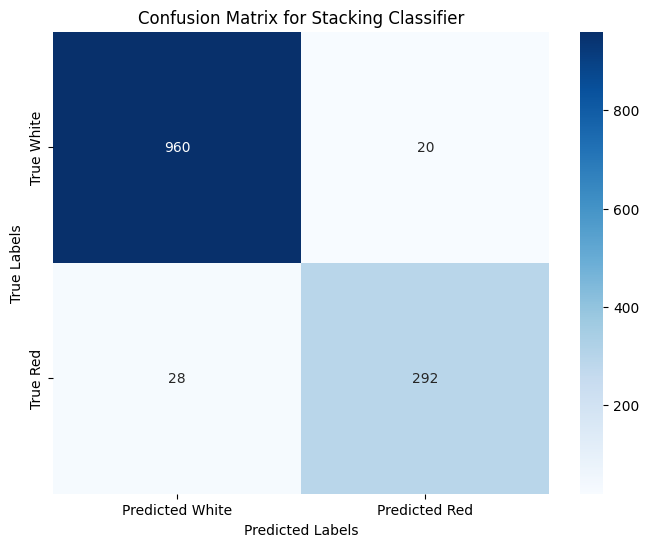

ROC AUC for Stacking Classifier: 0.9921301020408164


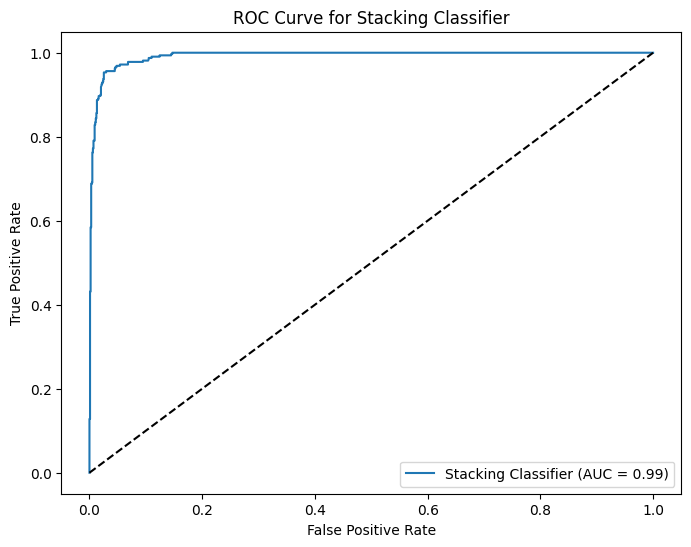

In [13]:
voting_model = VotingClassifier(
    estimators=[
        ('lr', best_lr_model),
        ('knn', best_knn_model),
        ('dt', best_dt_model),
        ('rf', best_rf_model),
        ('svm', best_svm_model)
    ],
    voting='soft'  # Use soft voting for probability-based averaging
)

voting_model.fit(X_train, y_train)
y_pred_voting = voting_model.predict(X_test)

print("\n Voting Classifier Model Performance:")
print(classification_report(y_test, y_pred_voting))
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_voting)}")



# Base models
base_models = [
    ('lr', best_lr_model),
    ('knn', best_knn_model),
    ('dt', best_dt_model),
    ('rf', best_rf_model),
    ('svm', best_svm_model)
]

# Meta-model (could use Logistic Regression or another model)
meta_model = LogisticRegression()

# Stacking Classifier
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_model)
stacking_model.fit(X_train, y_train)
y_pred_stacking = stacking_model.predict(X_test)

print("\n Stacking Classifier Model Performance:")
print(classification_report(y_test, y_pred_stacking))
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_voting)}")

plot_confusion_matrix_roc(voting_model, X_train, y_train, X_test, y_test, model_name="Voting Classifier")
plot_confusion_matrix_roc(stacking_model, X_train, y_train, X_test, y_test, model_name="Stacking Classifier")


# Add results to dictionary
add_results('Voting Classifier', y_test, y_pred_voting)
add_results('Stacking Classifier', y_test, y_pred_stacking)

## Improve Red Wine classification

### 8. Random Forest with SMOTE resampling

In [14]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imPipeline
from imblearn.under_sampling import RandomUnderSampler

# Example pipeline with SMOTE
smote = SMOTE(random_state=42)
scaler = MinMaxScaler()
model = RandomForestClassifier()

# Create a pipeline with resampling, scaling, and classification
smote_pipeline = imPipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('classifier', model)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model with SMOTE applied
smote_pipeline.fit(X_train, y_train)
y_pred = smote_pipeline.predict(X_test)

# Performance evaluation
print(classification_report(y_test, y_pred))
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")

# Add results
add_results('RF (SMOTE)', y_test, y_pred)

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       986
           1       0.87      0.93      0.90       314

    accuracy                           0.95      1300
   macro avg       0.93      0.94      0.93      1300
weighted avg       0.95      0.95      0.95      1300

Accuracy Score: 0.95


### 9. Random Forest with random undersampling

In [15]:
# Create the undersampling strategy to balance the classes
undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

# Scaling the features and then applying random undersampling
scaler = MinMaxScaler()
model = RandomForestClassifier()

# Create the pipeline with scaling and random undersampling
undersample_pipeline = imPipeline([
    ('scaler', scaler),
    ('undersampler', undersampler),
    ('classifier', model)
])

# Fit the pipeline
undersample_pipeline.fit(X_train, y_train)

# Predictions on the test set
y_pred = undersample_pipeline.predict(X_test)

# Performance evaluation
print(classification_report(y_test, y_pred))
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")

# Add results
add_results('RF (RUS)', y_test, y_pred)

              precision    recall  f1-score   support

           0       0.98      0.94      0.96       986
           1       0.84      0.95      0.89       314

    accuracy                           0.94      1300
   macro avg       0.91      0.94      0.93      1300
weighted avg       0.95      0.94      0.94      1300

Accuracy Score: 0.943076923076923


### 10. Random Forest with outliers removed

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters found by GridSearchCV for Random Forest:
{'classifier__bootstrap': True, 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Random Forest Model Performance after outlier removal:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       986
           1       0.90      0.90      0.90       314

    accuracy                           0.95      1300
   macro avg       0.94      0.94      0.94      1300
weighted avg       0.95      0.95      0.95      1300

Training Accuracy (Random Forest): 0.9847477512710208
Test Accuracy (Random Forest): 0.9538461538461539


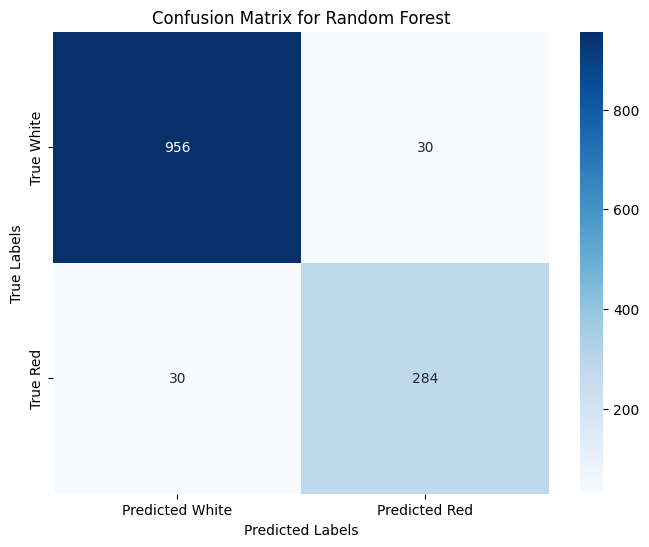

ROC AUC for Random Forest: 0.9832318057906227


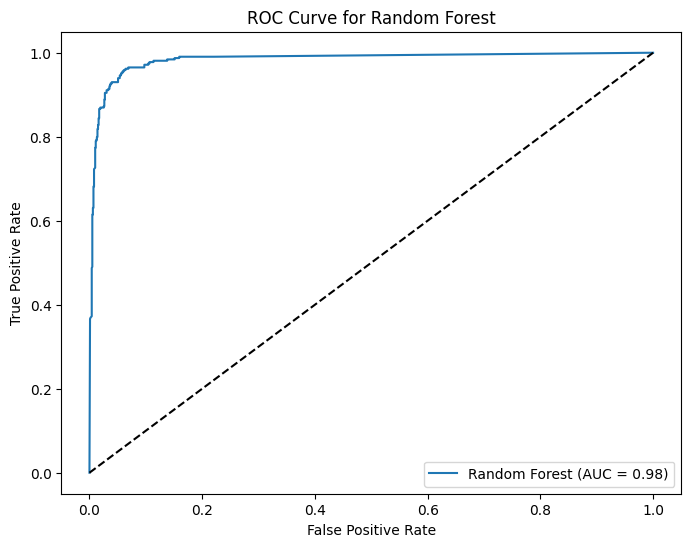

In [16]:
def remove_outliers_and_impute(X, y):
    # Calculate the z-scores
    z_scores = np.abs((X - X.mean()) / X.std())
    
    # Remove outliers (e.g., greater than 3 standard deviations away from the mean)
    mask = (z_scores < 3).all(axis=1)  # Mask to select non-outliers
    X_no_outliers = X[mask]
    y_no_outliers = y[mask]  # Adjust y_train to match X_train after removing outliers
    
    # Impute missing values using the median
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X_no_outliers)
    
    return X_imputed, y_no_outliers

param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False]
}


rf_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),  # Scaling for consistency
    ('classifier', RandomForestClassifier(random_state=42))
])

X_train_no_outliers, y_train_no_outliers = remove_outliers_and_impute(X_train, y_train)

grid_search_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=5, scoring='accuracy', verbose=1)
grid_search_rf.fit(X_train_no_outliers, y_train_no_outliers)

print("Best Parameters found by GridSearchCV for Random Forest:")
print(grid_search_rf.best_params_)

best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

print("\nRandom Forest Model Performance after outlier removal:")
print(classification_report(y_test, y_pred_rf))

# Training accuracy
train_accuracy_rf = best_rf_model.score(X_train_no_outliers, y_train_no_outliers)
print(f"Training Accuracy (Random Forest): {train_accuracy_rf}")
print(f"Test Accuracy (Random Forest): {accuracy_score(y_test, y_pred_rf)}")

y_pred_cv_rf = cross_val_predict(best_rf_model, X_train_no_outliers, y_train_no_outliers, cv=5)
plot_confusion_matrix_roc(best_rf_model, X_train_no_outliers, y_train_no_outliers, X_test, y_test, model_name="Random Forest")

# Add results
add_results('RF (Outlier removal)', y_test, y_pred_rf)

### Results

In [18]:
df_model_performance = pd.DataFrame(model_performance)
df_overall_performance = pd.DataFrame(overall_performance)

white_wine_table = df_model_performance[['Model', 'White Wine Precision', 'White Wine Recall', 'White Wine F1']]
red_wine_table = df_model_performance[['Model', 'Red Wine Precision', 'Red Wine Recall', 'Red Wine F1']]

# Display 3 tables
print("Overall Performance:")
display(df_overall_performance)

print("White Wine Performance:")
display(white_wine_table)

print("Red Wine Performance:")
display(red_wine_table)

Overall Performance:


,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.955385,0.939637,0.955290
1,KNN,0.965385,0.953216,0.965330
2,Decision Tree,0.957692,0.943061,0.957715
3,SVM,0.955385,0.939765,0.955337
4,Random Forest,0.963846,0.951137,0.963789
5,Voting Classifier,0.963077,0.950044,0.962998
6,Stacking Classifier,0.963077,0.949830,0.962918
7,RF (SMOTE),0.950000,0.933127,0.950491
8,RF (RUS),0.943077,0.925460,0.944192
9,RF (Outlier removal),0.953846,0.937016,0.953846


White Wine Performance:


,Model,White Wine Precision,White Wine Recall,White Wine F1
0,Logistic Regression,0.968496,0.972449,0.970468
1,KNN,0.975585,0.978571,0.977076
2,Decision Tree,0.972421,0.971429,0.971924
3,SVM,0.969450,0.971429,0.970438
4,Random Forest,0.974568,0.977551,0.976057
5,Voting Classifier,0.973577,0.977551,0.975560
6,Stacking Classifier,0.971660,0.979592,0.975610
7,RF (SMOTE),0.976215,0.957404,0.966718
8,RF (RUS),0.982030,0.942191,0.961698
9,RF (Outlier removal),0.969574,0.969574,0.969574


Red Wine Performance:


,Model,Red Wine Precision,Red Wine Recall,Red Wine F1
0,Logistic Regression,0.914557,0.903125,0.908805
1,KNN,0.933754,0.925000,0.929356
2,Decision Tree,0.912773,0.915625,0.914197
3,SVM,0.911950,0.906250,0.909091
4,Random Forest,0.930599,0.921875,0.926217
5,Voting Classifier,0.930380,0.918750,0.924528
6,Stacking Classifier,0.935897,0.912500,0.924051
7,RF (SMOTE),0.873874,0.926752,0.899536
8,RF (RUS),0.838983,0.945860,0.889222
9,RF (Outlier removal),0.904459,0.904459,0.904459


### Conclusion

#### Overall
Given the results, in general all models perform really well usually scoring above 0.9 for all three metrics.
KNN is the best overal model, as well as the best for white wine and red wine. It is closely followed by random forest, Voting classifier also does well. This suggests that ensemble methods in general may be a good fit for this classification problem.

#### White wine
For white wine, Random Forest also performs strong but scoring slightly less in all 3 metrics than KNN. The Stacking Classifier is also strong SMOTE and RUS models have slightly lower F1-scores than the standard classifiers, possibly due to the introduced synthetic samples affecting precision/recall balance.

#### Red wine
After KNN, Stacking Classifier and Random Forest follow closely in terms of performance. Resampling does show a higher recall for red wine and a lower precision, without affecting white wine classification too much. This suggests that while these models captured more actual red wines, they also misclassified some white wines as red, leading to lower precision. Higher recall is useful if identifying all red wines is more important than avoiding mislabeling white wines.


### Improvement
A potential improvement for this classification problem is two include more (correlated) features than just the top 2, as picked for this analysis. Then we could perform Principal Component Analysis (PCA): Analyze how a combination of the most correlated features impacts classification performance. Additionaly, Feature importance analysis can be done (e.g. SHAP, permutation importance, LASSO regression): Identify the most valuable predictors to refine the model. 

Another improvement would be to take into account possible non-linear transformation of features (e.g., log scaling, polynomial features) to capture hidden patterns. Aside from this we could explore potential interactions between features, especially those highly correlated with wine type.